# Prove dei grafi italia vs estero

In [1]:
# pacchetti necessari (file requirements.txt per l'installazione)

import pandas as pd
import networkx as nx
from pyvis.network import Network
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.colors as mcolors
import numpy as np
import os
from IPython.display import display
import itertools
import plotly.graph_objects as go
import scipy
import re
from plotly.subplots import make_subplots

### Prove grafo collaborazioni Udine con Italia vs Estero

In [2]:
import pandas as pd
import re

# 1. CARICAMENTO
df = pd.read_csv("nuovo_dataset.csv")
# Assicurati che ci sia una colonna Affiliations
df = df.dropna(subset=["Affiliations"])
# Separa autori e affiliazioni in strutture
# (dipende da come sono formattate: qui assumiamo delimitate da ';')
df["AffiliationsList"] = df["Affiliations"].str.split(";")

# 2. TROVA PAPER CON UDINE
def is_udine_aff(aff):
    return bool(re.search(r"\bUdine\b", aff, flags=re.IGNORECASE))
# tutti i paper con almeno una affiliazione Udine
df_udine = df[df["AffiliationsList"].apply(lambda affs: any(is_udine_aff(a) for a in affs))]

# 3. ESTRAI TUTTE LE COLLABORAZIONI
collab_affiliations = []

for idx, row in df_udine.iterrows():
    for aff in row["AffiliationsList"]:
        aff_clean = aff.strip()
        if not is_udine_aff(aff_clean):
            collab_affiliations.append(aff_clean)

# 4. CLASSIFICA ITALIANE VS ESTERE
def classify_affiliation(aff):
    aff = aff.lower()
    if "italy" in aff or aff.endswith("italy"):
        return "Italian"
    else:
        return "Foreign"

collab_df = pd.DataFrame({
    "Affiliation": collab_affiliations
})

collab_df["Type"] = collab_df["Affiliation"].apply(classify_affiliation)

# 5. RISULTATI: STATISTICHE
italian_collabs = collab_df[collab_df["Type"] == "Italian"]
foreign_collabs = collab_df[collab_df["Type"] == "Foreign"]

print("Numero collaborazioni italiane:", italian_collabs.shape[0])
print("Numero collaborazioni estere:", foreign_collabs.shape[0])

print("\nTop 10 istituzioni italiane:")
print(italian_collabs["Affiliation"].value_counts().head(10))

print("\nTop 10 istituzioni estere:")
print(foreign_collabs["Affiliation"].value_counts().head(10))


Numero collaborazioni italiane: 93
Numero collaborazioni estere: 185

Top 10 istituzioni italiane:
Affiliation
Università degli Studi di Padova, Padua, PD, Italy                                                           7
Istituto Nazionale di Fisica Nucleare, Sezione di Trieste, Trieste, TS, Italy                                5
Department of Diagnostic Imaging, Fondazione Poliambulanza Istituto Ospedaliero, Brescia, Italy              4
Università degli Studi di Trieste, Trieste, TS, Italy                                                        3
Istituto Nazionale di Biostrutture e Biosistemi, Rome, RM, Italy                                             3
Department of Neurological Sciences, Università Vita-Salute San Raffaele, Milan, MI, Italy                   3
Department of Medical Sciences and Public Health, Università degli Studi di Cagliari, Cagliari, CA, Italy    3
Politecnico di Milano, Milan, MI, Italy                                                                      3
T

In [1]:
import pandas as pd
import networkx as nx
import re
import plotly.graph_objects as go

# 1. CARICAMENTO DATI
df = pd.read_csv("nuovo_dataset.csv")
df = df.dropna(subset=["Affiliations"])
df["AffiliationsList"] = df["Affiliations"].str.split(";")

# 2. IDENTIFICAZIONE UDINE
def is_udine(aff):
    return bool(re.search(r"\bUdine\b", aff, re.IGNORECASE))

df_udine = df[df["AffiliationsList"].apply(lambda affs: any(is_udine(a) for a in affs))]


# 3. ESTRAZIONE COLLABORAZIONI
collaborations = []
for _, row in df_udine.iterrows():
    for aff in row["AffiliationsList"]:
        aff = aff.strip()
        if not is_udine(aff):
            collaborations.append(aff)

# 4. CLASSIFICAZIONE ITALIA / ESTERO
def classify_affiliation(aff):
    aff = aff.lower()
    if "italy" in aff:
        return "Italian"
    else:
        return "Foreign"

collab_df = pd.DataFrame({"Affiliation": collaborations})
collab_df["Type"] = collab_df["Affiliation"].apply(classify_affiliation)
collab_counts = collab_df.groupby(["Affiliation", "Type"]).size().reset_index(name="weight")
collab_counts = collab_counts[collab_counts["weight"] >= 2]

# 5. COSTRUZIONE GRAFO
G = nx.Graph()
G.add_node("University of Udine", role="udine")
for _, row in collab_counts.iterrows():
    G.add_node(row["Affiliation"], role=row["Type"], weight=row["weight"])
    G.add_edge("University of Udine", row["Affiliation"], weight=row["weight"])

# 6. POSIZIONAMENTO
pos = nx.spring_layout(G, seed=42)


# 7. CREAZIONE TRACCE PER PLOTLY
# archi
edge_x = []
edge_y = []
for u, v, d in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines'
)

# nodi
node_x = []
node_y = []
node_text = []
node_color = []
node_size = []

for node, data in G.nodes(data=True):
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f"{node}<br>Collaborazioni: {data.get('weight', 0)}")
    role = data["role"]
    node_color.append('red' if role=="udine" else 'skyblue' if role=="Italian" else 'orange')
    # dimensione proporzionale al numero di collaborazioni
    size = 25 if role=="udine" else 10 + 5 * data.get('weight', 1)
    node_size.append(size)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    text=node_text,
    hoverinfo='text',
    marker=dict(
        color=node_color,
        size=node_size,
        line_width=2
    )
)

# 8. FIGURA FINALE
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title="Collaborazioni dell’Università di Udine\nItalia vs Estero",
                    title_x=0.5,
                    showlegend=False,
                    hovermode='closest',
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
                ))

fig.show()


In [4]:
import pandas as pd
import networkx as nx
import re
import plotly.graph_objects as go

# =====================================
# 1. CARICAMENTO DATI
# =====================================
df = pd.read_csv("nuovo_dataset.csv")
df = df.dropna(subset=["Affiliations"])
df["AffiliationsList"] = df["Affiliations"].str.split(";")

# =====================================
# 2. IDENTIFICAZIONE UDINE
# =====================================
def is_udine(aff):
    return bool(re.search(r"\bUdine\b", aff, re.IGNORECASE))

df_udine = df[df["AffiliationsList"].apply(lambda affs: any(is_udine(a) for a in affs))]

# =====================================
# 3. ESTRAZIONE COLLABORAZIONI
# =====================================
collaborations = []
for _, row in df_udine.iterrows():
    for aff in row["AffiliationsList"]:
        aff = aff.strip()
        if not is_udine(aff):
            collaborations.append(aff)

# =====================================
# 4. CLASSIFICAZIONE ITALIA / ESTERO
# =====================================
def classify_affiliation(aff):
    aff = aff.lower()
    if "italy" in aff:
        return "Italian"
    else:
        return "Foreign"

collab_df = pd.DataFrame({"Affiliation": collaborations})
collab_df["Type"] = collab_df["Affiliation"].apply(classify_affiliation)
collab_counts = collab_df.groupby(["Affiliation", "Type"]).size().reset_index(name="weight")
collab_counts = collab_counts[collab_counts["weight"] >= 2]

# =====================================
# 5. COSTRUZIONE GRAFO
# =====================================
G = nx.Graph()
G.add_node("University of Udine", role="udine")
for _, row in collab_counts.iterrows():
    G.add_node(row["Affiliation"], role=row["Type"], weight=row["weight"])
    G.add_edge("University of Udine", row["Affiliation"], weight=row["weight"])

# =====================================
# 6. POSIZIONAMENTO
# =====================================
pos = nx.spring_layout(G, seed=42)

# =====================================
# 7. CREAZIONE TRACCE PER PLOTLY
# =====================================
edge_x, edge_y = [], []
for u, v, d in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines',
    showlegend=False
)

node_x, node_y, node_text, node_color, node_size = [], [], [], [], []

for node, data in G.nodes(data=True):
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f"{node}<br>Collaborazioni: {data.get('weight', 0)}")
    role = data["role"]
    node_color.append('red' if role=="udine" else 'skyblue' if role=="Italian" else 'orange')
    size = 25 if role=="udine" else 10 + 5 * data.get('weight', 1)
    node_size.append(size)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    text=node_text,
    hoverinfo='text',
    showlegend=False,   
    marker=dict(
        color=node_color,
        size=node_size,
        line_width=2
    )
)


# =====================================
# 8. LEGENDA COLORI
# =====================================
legend_traces = [
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(size=15, color='red'), name='Udine'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(size=15, color='skyblue'), name='Italia'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(size=15, color='orange'), name='Estero')
]

# =====================================
# 9. FIGURA FINALE
# =====================================
fig = go.Figure(data=[edge_trace, node_trace] + legend_traces,
                layout=go.Layout(
                    title="Collaborazioni dell’Università di Udine\nItalia vs Estero",
                    title_x=0.5,
                    showlegend=True,
                    legend=dict(
                        title_text="Legenda",
                        x=1.02, y=0.95,
                        traceorder="normal",
                        bgcolor="rgba(0,0,0,0)",
                        bordercolor="Black",
                        borderwidth=1
                    ),
                    hovermode='closest',
                    margin=dict(l=50, r=200, t=50, b=50),
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
                )
)

fig.show()

# =====================================
# 10. TABELLA TOP 3 COLLABORAZIONI (PLOTLY)
# =====================================

# Top 3 italiane ed estere
top_italy = (
    collab_counts[collab_counts["Type"] == "Italian"]
    .sort_values(by="weight", ascending=False)
    .head(3)
)

top_foreign = (
    collab_counts[collab_counts["Type"] == "Foreign"]
    .sort_values(by="weight", ascending=False)
    .head(3)
)

# Allineiamo le righe (nel caso siano < 3)
def pad_df(df, n=3):
    while len(df) < n:
        df = pd.concat([df, pd.DataFrame([{
            "Affiliation": "",
            "weight": "",
            "Type": ""
        }])])
    return df

top_italy = pad_df(top_italy)
top_foreign = pad_df(top_foreign)

# Creazione tabella Plotly
table_fig = go.Figure(data=[go.Table(
    header=dict(
        values=[
            "<b>Università italiane (Top 3)</b>",
            "<b>Collaborazioni</b>",
            "<b>Università estere (Top 3)</b>",
            "<b>Collaborazioni</b>"
        ],
        fill_color="lightgrey",
        align="left",
        font=dict(size=13)
    ),
    cells=dict(
        values=[
            top_italy["Affiliation"].tolist(),
            top_italy["weight"].tolist(),
            top_foreign["Affiliation"].tolist(),
            top_foreign["weight"].tolist()
        ],
        fill_color="white",
        align="left",
        font=dict(size=12),
        height=28
    )
)])

table_fig.update_layout(
    title="Top collaborazioni dell’Università di Udine",
    title_x=0.5,
    width=900,
    height=300,
    margin=dict(l=20, r=20, t=60, b=20)
)

table_fig.show()


In [5]:
import pandas as pd
import networkx as nx
import re
import plotly.graph_objects as go
from collections import Counter

df = pd.read_csv("nuovo_dataset.csv")
df = df.dropna(subset=["Affiliations"])
df["AffiliationsList"] = df["Affiliations"].str.split(";")

def is_udine(aff):
    return bool(re.search(r"\bUdine\b", aff, re.IGNORECASE))

df_udine = df[df["AffiliationsList"].apply(lambda affs: any(is_udine(a) for a in affs))]

collaborations = [aff.strip() for _row in df_udine.iterrows() for aff in _row[1]["AffiliationsList"] if not is_udine(aff)]

def classify_affiliation(aff):
    aff_lower = aff.lower()
    italian_keywords = ["italy", "udine", "padova", "padua", "milano", "roma"]
    return "Italian" if any(kw in aff_lower for kw in italian_keywords) else "Foreign"

collab_df = pd.DataFrame({"Affiliation": collaborations})
collab_df["Type"] = collab_df["Affiliation"].apply(classify_affiliation)
collab_counts = collab_df.groupby(["Affiliation", "Type"]).size().reset_index(name="weight")
collab_counts = collab_counts[collab_counts["weight"] >= 1]

# Keywords FIX
df_udine = df_udine.copy()
df_udine['Keywords'] = df_udine['Author Keywords'].fillna('') + ';' + df_udine['Index Keywords'].fillna('')
all_keywords = []
for kw_str in df_udine['Keywords']:
    if pd.notna(kw_str):
        all_keywords.extend([k.strip().lower() for k in re.split(r'[;,]', str(kw_str)) if k.strip()])

top_topics = [word for word, count in Counter(all_keywords).most_common(10)]
print("Top 10 Topics trovati:", top_topics)  # Es: ['algorithms', 'deep learning', 'quantum'...][file:1]

collab_topics = {aff: Counter() for aff in collab_counts['Affiliation']}
for _, row in df_udine.iterrows():
    affs = [a.strip() for a in row["AffiliationsList"]]
    if any(is_udine(a) for a in affs):
        kw_str_lower = str(row['Keywords']).lower()
        topics_in_paper = [t for t in top_topics if t in kw_str_lower]
        for aff in affs:
            if not is_udine(aff) and aff in collab_topics:
                for t in topics_in_paper:
                    collab_topics[aff][t] += 1

# Grafo Bipartito
G = nx.Graph()
G.add_node("University of Udine", bipartite=0, role="udine")
for _, row in collab_counts.iterrows():
    aff = row["Affiliation"]
    G.add_node(aff, bipartite=0, role=row["Type"], weight=row["weight"])
    for topic, wt in collab_topics[aff].items():
        if wt > 0:
            G.add_node(topic, bipartite=1)
            G.add_edge(aff, topic, weight=wt)
    G.add_edge("University of Udine", aff, weight=row["weight"])

print("Nodi grafo:", G.number_of_nodes(), "Archi:", G.number_of_edges())  # Debug[file:1]

# Plot (stesso)
pos = nx.spring_layout(G, seed=42)
edge_x, edge_y = [], []
for u, v, d in G.edges(data=True):
    x0, y0 = pos[u]; x1, y1 = pos[v]
    edge_x += [x0, x1, None]; edge_y += [y0, y1, None]

edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=1, color='#888'), hoverinfo='none', mode='lines')

node_x, node_y, node_text, node_color, node_size = [], [], [], [], []
for node, data in G.nodes(data=True):
    x, y = pos[node]
    node_x.append(x); node_y.append(y)
    role = data.get('role', 'topic')
    wt = data.get('weight', G.degree(node))
    node_text.append(f"{node}<br>Collabs/Topics: {wt}")
    if role == "udine": color, size = 'red', 40
    elif role == "Italian": color, size = 'skyblue', 25 + 5 * wt
    elif role == "Foreign": color, size = 'orange', 25 + 5 * wt
    else: color, size = 'green', 20
    node_color.append(color); node_size.append(size)

node_trace = go.Scatter(x=node_x, y=node_y, mode='markers', text=node_text, hoverinfo='text',
                       marker=dict(color=node_color, size=node_size, line_width=2), name='Nodi')

legend_traces = [
    go.Scatter(marker=dict(size=20, color='red'), name='Udine'),
    go.Scatter(marker=dict(size=20, color='skyblue'), name='Italia'),
    go.Scatter(marker=dict(size=20, color='orange'), name='Estero'),
    go.Scatter(marker=dict(size=20, color='green'), name='Topics')
]

fig = go.Figure(data=[edge_trace, node_trace] + legend_traces,
                layout=go.Layout(title="Udine Collaborazioni + Topics di Ricerca", showlegend=True,
                                hovermode='closest', margin=dict(l=40, r=200, t=60, b=40),
                                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)))
fig.show()

print("\nTop Collaborazioni:")
print(collab_counts.head())


Top 10 Topics trovati: ['human', 'male', 'female', 'article', 'aged', 'humans', 'middle aged', 'adult', 'epilepsy', 'priority journal']
Nodi grafo: 185 Archi: 742



Top Collaborazioni:
                                         Affiliation     Type  weight
0     23andMe Inc., Mountain View, CA, United States  Foreign       1
1  Abdus Salam International Centre for Theoretic...  Italian       1
2  Advanced Microelectronic Center Aachen, Gesell...  Foreign       1
3  Alma Mater Studiorum Università di Bologna, Bo...  Italian       2
4  Appalachian State University, Boone, NC, Unite...  Foreign       1


In [6]:
import pandas as pd
import networkx as nx
import re
import plotly.graph_objects as go
from collections import Counter
import numpy as np

# === PREPARAZIONE DATI (stessa base) ===
df = pd.read_csv("nuovo_dataset.csv")
df = df.dropna(subset=["Affiliations"])
df["AffiliationsList"] = df["Affiliations"].str.split(";")

def is_udine(aff): return bool(re.search(r"\bUdine\b", aff, re.IGNORECASE))
def classify_affiliation(aff):
    aff_lower = aff.lower()
    italian_keywords = ["italy", "udine", "padova", "padua", "milano", "roma", "bozen"]
    return "Italian" if any(kw in aff_lower for kw in italian_keywords) else "Foreign"

df_udine = df[df["AffiliationsList"].apply(lambda affs: any(is_udine(a) for a in affs))]
df_udine['Keywords'] = df_udine['Author Keywords'].fillna('') + ';' + df_udine['Index Keywords'].fillna('')

# === ESTRAZIONE TOPICS CENTRALI ===
all_keywords = []
for kw_str in df_udine['Keywords']:
    if pd.notna(kw_str):
        all_keywords.extend([k.strip().lower() for k in re.split(r'[;,]', str(kw_str)) if len(k.strip()) > 2])

topic_freq = Counter(all_keywords)
top_topics = [t for t, f in topic_freq.most_common(15)]  # 15 topic principali
print("🏆 Top 15 Topics:", top_topics)

# === MAPPATURA Topic -> Università (per tipo) ===
topic_unis = {topic: {'Udine': 0, 'Italian': 0, 'Foreign': 0} for topic in top_topics}

for _, row in df_udine.iterrows():
    paper_topics = [t for t in top_topics if t in str(row['Keywords']).lower()]
    affs = [a.strip() for a in row["AffiliationsList"]]
    
    for topic in paper_topics:
        for aff in affs:
            if is_udine(aff):
                topic_unis[topic]['Udine'] += 1
            elif classify_affiliation(aff) == "Italian":
                topic_unis[topic]['Italian'] += 1
            else:
                topic_unis[topic]['Foreign'] += 1

# === GRAFO TOPIC-CENTRICO ===
G = nx.Graph()
TOPIC_SIZE_BASE = 30

# 1. Aggiungi TOPICS come nodi principali (grandi, colorati)
for i, topic in enumerate(top_topics):
    total_mentions = sum(topic_unis[topic].values())
    udine_weight = topic_unis[topic]['Udine'] / max(total_mentions, 1)
    
    G.add_node(topic, type='topic', 
               size=TOPIC_SIZE_BASE + 20 * udine_weight,  # Udine topics più grandi
               udine_weight=udine_weight,
               total_mentions=total_mentions,
               color=f'hsl({30 + i*15 % 360}, 70%, 50%)')  # Colori arcobaleno

# 2. Aggiungi Università come satelliti (piccoli)
unis = set()
for _, row in df_udine.iterrows():
    for aff in [a.strip() for a in row["AffiliationsList"]]:
        if not is_udine(aff):
            unis.add(aff)

for uni in list(unis)[:8]:  # Top 8 università
    uni_type = classify_affiliation(uni)
    G.add_node(uni, type='uni', role=uni_type)

# 3. Connetti Topics -> Università (solo se >0 occorrenze)
for topic in top_topics:
    for uni in unis:
        if topic_unis[topic][classify_affiliation(uni)] > 0 or topic_unis[topic]['Udine'] > 0:
            if uni in G.nodes and topic in G.nodes:
                G.add_edge(topic, uni, weight=1)

print(f"📊 Grafo: {G.number_of_nodes()} nodi, {G.number_of_edges()} archi")

# === VISUALIZZAZIONE ===
pos = nx.spring_layout(G, k=3, iterations=50, seed=42)  # Topics si espandono

edge_x, edge_y = [], []
for u, v, d in G.edges(data=True):
    x0, y0 = pos[u]; x1, y1 = pos[v]
    edge_x += [x0, x1, None]; edge_y += [y0, y1, None]

edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=1, color='#bbb'), 
                       hoverinfo='none', mode='lines')

node_x, node_y, node_text, node_color, node_size = [], [], [], [], []
for node, data in G.nodes(data=True):
    x, y = pos[node]
    node_x.append(x); node_y.append(y)
    
    if data.get('type') == 'topic':
        text = f"<b>{node}</b><br>📊 Tot: {data['total_mentions']}<br>🎓 Udine: {data['udine_weight']:.1%}<br>🌍 Internaz.: {data.get('Foreign',0)}"
        node_color.append(data['color'])
        node_size.append(data['size'])
    else:  # università
        text = f"{node}<br>🇮🇹 {data.get('role', 'N/A')}"
        role = data['role']
        node_color.append('skyblue' if role=='Italian' else 'orange')
        node_size.append(12)

node_trace = go.Scatter(x=node_x, y=node_y, mode='markers', text=node_text, 
                       hoverinfo='text', marker=dict(color=node_color, size=node_size, line_width=2))

# Legenda topics top
legend_topics = [go.Scatter(x=[None], y=[None], mode='markers', 
                           marker=dict(size=25, color=topics['color']), 
                           name=f"{topic[:20]}...") 
                for topic, topics in list(G.nodes(data=True))[:5] if topics.get('type')=='topic']

fig = go.Figure(data=[edge_trace, node_trace] + legend_topics,
                layout=go.Layout(
                    title="🌟 TOPICS Udine: Dove Collabora l'Università",
                    title_x=0.5, showlegend=True,
                    hovermode='closest', 
                    margin=dict(l=40, r=10, t=80, b=40),
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    legend=dict(x=1.02, y=0.99)))
fig.show()

# === TABELLA RIEPILOGO ===
topic_table = pd.DataFrame({
    'Topic': top_topics,
    'Udine': [topic_unis[t]['Udine'] for t in top_topics],
    '% Udine': [topic_unis[t]['Udine']/sum(topic_unis[t].values())*100 for t in top_topics],
    'Italia': [topic_unis[t]['Italian'] for t in top_topics],
    'Estero': [topic_unis[t]['Foreign'] for t in top_topics]
}).round(1)
print("\n📋 Topic per Collaborazione:")
print(topic_table.head(10))


🏆 Top 15 Topics: ['human', 'male', 'female', 'article', 'aged', 'humans', 'middle aged', 'adult', 'epilepsy', 'priority journal', 'retrospective study', 'rewriting logic', 'major clinical study', 'maude', 'clinical article']
📊 Grafo: 23 nodi, 120 archi



📋 Topic per Collaborazione:
              Topic  Udine  % Udine  Italia  Estero
0             human    166     53.5      31     113
1              male    127     51.6      27      92
2            female    105     47.7      23      92
3           article    127     67.2      19      43
4              aged     99     55.9      18      60
5            humans    117     52.0      25      83
6       middle aged     55     42.0      17      59
7             adult     84     64.6      11      35
8          epilepsy     45     73.8       5      11
9  priority journal     62     52.5      16      40


In [7]:
import pandas as pd
import networkx as nx
import re
import plotly.graph_objects as go
from collections import Counter

# === PREPARAZIONE DATI ===
df = pd.read_csv("nuovo_dataset.csv")
df = df.dropna(subset=["Affiliations"])
df["AffiliationsList"] = df["Affiliations"].str.split(";")

def is_udine(aff): return bool(re.search(r"\bUdine\b", aff, re.IGNORECASE))
def classify_affiliation(aff):
    aff_lower = aff.lower()
    italian_keywords = ["italy", "udine", "padova", "padua", "milano", "roma", "bozen"]
    return "Italian" if any(kw in aff_lower for kw in italian_keywords) else "Foreign"

df_udine = df[df["AffiliationsList"].apply(lambda affs: any(is_udine(a) for a in affs))]
df_udine['Keywords'] = df_udine['Author Keywords'].fillna('') + ';' + df_udine['Index Keywords'].fillna('')

# === TOPICS CENTRALI ===
all_keywords = []
for kw_str in df_udine['Keywords']:
    if pd.notna(kw_str):
        all_keywords.extend([k.strip().lower() for k in re.split(r'[;,]', str(kw_str)) if len(k.strip()) > 2])

topic_freq = Counter(all_keywords)
top_topics = [t for t, f in topic_freq.most_common(12)]
print("🏆 Top Topics:", top_topics)

# === DATI FIXATI ===
topic_details = {}
for topic in top_topics:
    topic_details[topic] = {'Udine': 0, 'Italian': 0, 'Foreign': 0, 'papers': [], 'authors': []}

for idx, row in df_udine.iterrows():
    paper_topics = [t for t in top_topics if t in str(row['Keywords']).lower()]
    affs = [a.strip() for a in row["AffiliationsList"]]
    paper_title = row['Title'][:60] + "..." if len(row['Title']) > 60 else row['Title']
    
    for topic in paper_topics:
        # CONTA SOLO NUMERICI
        for aff in affs:
            if is_udine(aff):
                topic_details[topic]['Udine'] += 1
            elif classify_affiliation(aff) == "Italian":
                topic_details[topic]['Italian'] += 1
            else:
                topic_details[topic]['Foreign'] += 1
        topic_details[topic]['papers'].append(paper_title)
        topic_details[topic]['authors'].append(row['Authors'])

# === GRAFO INTERATTIVO ===
G = nx.Graph()

# Topics (nodi GRANDI) - FIXATO
for topic in top_topics:
    # ✅ FIX: Somma solo valori numerici
    numeric_counts = topic_details[topic]['Udine'] + topic_details[topic]['Italian'] + topic_details[topic]['Foreign']
    udine_pct = topic_details[topic]['Udine'] / numeric_counts if numeric_counts > 0 else 0
    
    G.add_node(topic, 
               type='topic',
               size=40 + 25*udine_pct,
               total_mentions=numeric_counts,
               udine_pct=udine_pct,
               italian=topic_details[topic]['Italian'],
               foreign=topic_details[topic]['Foreign'],
               papers_count=len(set(topic_details[topic]['papers'])),
               top_paper=topic_details[topic]['papers'][0] if topic_details[topic]['papers'] else "",
               color=f'hsl({hash(topic) % 360}, 70%, 50%)')

# Università (nodi PICCOLI)
unis = {}
for _, row in df_udine.iterrows():
    for aff in [a.strip() for a in row["AffiliationsList"]]:
        if not is_udine(aff):
            unis[aff] = unis.get(aff, 0) + 1

top_unis = sorted(unis.items(), key=lambda x: x[1], reverse=True)[:10]
for uni, count in top_unis:
    uni_type = classify_affiliation(uni)
    G.add_node(uni, type='uni', role=uni_type, collab_count=count,
               short_name=uni.split(',')[0][:25])

# Connessioni
for topic in top_topics:
    for uni_name, _ in top_unis:
        uni_type = classify_affiliation(uni_name)
        if topic_details[topic][uni_type] > 0:
            G.add_edge(topic, uni_name, weight=1)

print(f"🌐 Grafo: {G.number_of_nodes()} nodi | {G.number_of_edges()} archi")

# === VISUALIZZAZIONE ===
pos = nx.spring_layout(G, k=4, iterations=80, seed=42)

edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]; x1, y1 = pos[edge[1]]
    edge_x += [x0, x1, None]; edge_y += [y0, y1, None]

edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=2, color='#666'), 
                       hoverinfo='none', mode='lines')

node_x, node_y, node_text, node_color, node_size, node_labels = [], [], [], [], [], []
for node, data in G.nodes(data=True):
    x, y = pos[node]
    node_x.append(x); node_y.append(y)
    
    if data['type'] == 'topic':
        text = f"""
        <b>🔬 {node.title()}</b><br>
        📊 Papers: {data['papers_count']}<br>
        🎓 Udine: {data['udine_pct']:.0%}<br>
        🇮🇹 Italia: {data['italian']}<br>
        🌍 Estero: {data['foreign']}<br>
        📄 {data['top_paper']}
        """
        node_color.append(data['color'])
        node_size.append(data['size'])
        node_labels.append(node[:12])
    else:
        text = f"<b>{data['short_name']}</b><br>Collabs: {data['collab_count']}<br>{data['role'].title()}"
        role = data['role']
        node_color.append('lightblue' if role=='Italian' else '#ff9500')
        node_size.append(15)
        node_labels.append(node[:12])

node_trace = go.Scatter(x=node_x, y=node_y, mode='markers+text',
                       text=node_labels, textposition="middle center",
                       hovertext=node_text, hoverinfo='text',
                       marker=dict(size=node_size, color=node_color, line=dict(width=3, color='white')),
                       textfont=dict(size=9, color='white'), name='Nodi')

legend_traces = [
    go.Scatter(marker=dict(size=30, color='gold'), name='Topic (Udine %)'),
    go.Scatter(marker=dict(size=15, color='lightblue'), name='Italia'),
    go.Scatter(marker=dict(size=15, color='#ff9500'), name='Estero')
]

fig = go.Figure(data=[edge_trace, node_trace] + legend_traces)
fig.update_layout(
    title="🌟 TOPICS RESEARCH Udine - Interattivo",
    showlegend=True, hovermode='closest',
    margin=dict(l=20, r=20, t=80, b=20),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
)
fig.show()

print("✅ GRAFO INTERATTIVO PRONTO!")
print("\n📊 Top Topics Udine:")
for topic in top_topics[:5]:
    udine_pct = topic_details[topic]['Udine'] / (topic_details[topic]['Udine'] + 
                                                 topic_details[topic]['Italian'] + 
                                                 topic_details[topic]['Foreign'])
    print(f"  {topic}: {topic_details[topic]['Udine']} Udine ({udine_pct:.0%})")


🏆 Top Topics: ['human', 'male', 'female', 'article', 'aged', 'humans', 'middle aged', 'adult', 'epilepsy', 'priority journal', 'retrospective study', 'rewriting logic']
🌐 Grafo: 22 nodi | 120 archi


✅ GRAFO INTERATTIVO PRONTO!

📊 Top Topics Udine:
  human: 166 Udine (54%)
  male: 127 Udine (52%)
  female: 105 Udine (48%)
  article: 127 Udine (67%)
  aged: 99 Udine (56%)


In [8]:
import pandas as pd
import networkx as nx
import re
import plotly.graph_objects as go
from collections import Counter, defaultdict
import numpy as np

# === CARICAMENTO DATI ===
df = pd.read_csv("nuovo_dataset.csv")
df = df.dropna(subset=["Affiliations"])
df["AffiliationsList"] = df["Affiliations"].str.split(";")

def is_udine(aff): 
    return bool(re.search(r"\bUdine\b", aff, re.IGNORECASE))

def classify_affiliation(aff):
    aff_lower = aff.lower()
    italian_keywords = ["italy", "udine", "padova", "padua", "milano", "roma", "bozen", "trieste"]
    return "Italian" if any(kw in aff_lower for kw in italian_keywords) else "Foreign"

df_udine = df[df["AffiliationsList"].apply(lambda affs: any(is_udine(a) for a in affs))]

# === MACRO AREE di RICERCA (definite dai topics dominanti) ===
df_udine['Keywords'] = df_udine['Author Keywords'].fillna('') + ';' + df_udine['Index Keywords'].fillna('')
all_keywords = []
for kw_str in df_udine['Keywords']:
    if pd.notna(kw_str):
        all_keywords.extend([k.strip().lower() for k in re.split(r'[;,]', str(kw_str)) if len(k.strip()) > 2])

keyword_freq = Counter(all_keywords)
print("Top Keywords grezzi:", keyword_freq.most_common(15))

# 🎯 MACRO AREE IDENTIFICATE DAL DATASET
MACRO_AREE = {
    '🧮 ALGORITHMS & AI': ['algorithms', 'optimization', 'combinatorial', 'hyper-heuristic', 'simulated annealing'],
    '🔬 DEEP LEARNING': ['deep learning', 'artificial intelligence', 'machine learning', 'neural network'],
    '⚛️ QUANTUM PHYSICS': ['quantum', 'entanglement', 'quantum physics'],
    '📊 MATHEMATICS': ['mathematics', 'lyapunov', 'stability', 'model'],
    '🏥 MEDICAL AI': ['prostate cancer', 'biopsy', 'mri', 'cancer'],
    '🔬 CHEMISTRY': ['eutectic solvents', 'bragg-williams', 'thermodynamics', 'solvent'],
    '📚 PHYSICS ED': ['physics education', 'teaching', 'learning']
}

# === ASSEGNAZIONE A MACRO AREE ===
df_udine['MacroArea'] = 'Other'
for macro, keywords in MACRO_AREE.items():
    mask = df_udine['Keywords'].str.lower().str.contains('|'.join(keywords), na=False, case=False)
    df_udine.loc[mask, 'MacroArea'] = macro

macro_counts = df_udine['MacroArea'].value_counts()
print("\n📈 MACRO AREE UniUD:")
for area, count in macro_counts.items():
    print(f"  {area}: {count} papers")

# === GRAFO MACRO AREE + PARTNER ===
G = nx.Graph()

# 1. MACRO AREE (NODI GRANDI per numero papers + grado futuro)
for macro_area in macro_counts.index:
    papers_count = macro_counts[macro_area]
    G.add_node(macro_area, 
               type='macro_area',
               papers=papers_count,
               degree=0)  # Verrà calcolato dopo

# 2. Università partner principali (per area)
uni_per_area = defaultdict(lambda: defaultdict(int))

for _, row in df_udine.iterrows():
    macro = row['MacroArea']
    affs = [a.strip() for a in row["AffiliationsList"]]
    
    for aff in affs:
        if not is_udine(aff):
            uni_type = classify_affiliation(aff)
            uni_per_area[macro][aff] += 1

# Aggiungi top 3 università per macro area
top_unis_per_macro = {}
for macro, unis in uni_per_area.items():
    top_unis = sorted(unis.items(), key=lambda x: x[1], reverse=True)[:3]
    top_unis_per_macro[macro] = top_unis
    
    for uni, collab_count in top_unis:
        uni_type = classify_affiliation(uni)
        short_name = uni.split(',')[0][:20]
        G.add_node(uni, type='uni', role=uni_type, short_name=short_name, collab_count=collab_count)

# 3. CONNESSIONI MACRO -> UNI
for macro, top_unis in top_unis_per_macro.items():
    for uni, count in top_unis:
        G.add_edge(macro, uni, weight=count)

# 4. CALCOLA GRADI (per dimensionare nodi macro)
for node in G.nodes:
    if G.nodes[node]['type'] == 'macro_area':
        G.nodes[node]['degree'] = G.degree(node)
        papers = G.nodes[node]['papers']
        # Dimensione = papers * degree (importanza)
        G.nodes[node]['size'] = 30 + 15*papers/5 + 10*G.degree(node)

print(f"\n🌐 Grafo: {G.number_of_nodes()} nodi | {G.number_of_edges()} archi")

# === VISUALIZZAZIONE ===
pos = nx.spring_layout(G, k=5, iterations=100, seed=42)

# Edge traces
edge_x, edge_y, edge_weights = [], [], []
for edge in G.edges(data=True):
    x0, y0 = pos[edge[0]]; x1, y1 = pos[edge[1]]
    edge_x += [x0, x1, None]; edge_y += [y0, y1, None]
    edge_weights.append(edge[2]['weight'])

edge_trace = go.Scatter(x=edge_x, y=edge_y,
                       line=dict(width=3, color='#444'),
                       hoverinfo='none', mode='lines')

# Node traces
node_x, node_y, node_text, node_color, node_size, node_labels = [], [], [], [], [], []

for node, data in G.nodes(data=True):
    x, y = pos[node]
    node_x.append(x); node_y.append(y)
    
    if data['type'] == 'macro_area':
        label = node.split(' ')[0][:10]  # Primo parola
        text = f"""
        <b>{node}</b><br>
        📊 Papers: {data['papers']}<br>
        🌐 Partner: {data['degree']}<br>
        💪 Score: {data['size']:.0f}<br>
        <b>Top Partner:</b><br>{list(top_unis_per_macro[node])[0][0] if node in top_unis_per_macro else 'N/A'}
        """
        node_color.append('#1f77b4')
        node_size.append(data['size'])
        node_labels.append(label)
    else:  # Università
        label = data['short_name']
        text = f"{data['short_name']}<br>🤝 {data['collab_count']} papers<br>{data['role'].title()}"
        role = data['role']
        node_color.append('lightblue' if role=='Italian' else '#ff9500')
        node_size.append(18)
        node_labels.append(label[:12])

node_trace = go.Scatter(x=node_x, y=node_y,
                       mode='markers+text',
                       text=node_labels,
                       textposition="middle center",
                       hoverinfo='text',
                       hovertext=node_text,
                       marker=dict(size=node_size, color=node_color, 
                                 line=dict(width=4, color='white'), opacity=0.9),
                       textfont=dict(size=10, color='white', family='Arial Black'),
                       name='Nodi')

# Legenda
legend_traces = [
    go.Scatter(marker=dict(size=40, color='#1f77b4', line=dict(width=4,color='white')), 
               name='Macro Aree (grado×papers)'),
    go.Scatter(marker=dict(size=18, color='lightblue'), name='Partner Italia'),
    go.Scatter(marker=dict(size=18, color='#ff9500'), name='Partner Estero')
]

fig = go.Figure(data=[edge_trace, node_trace] + legend_traces)
fig.update_layout(
    title=dict(text="<b>🎯 MACRO AREE RICERCA UniUD</b><br><sup>Nodi grandi = (Papers × Partner) | Hover per dettagli</sup>", 
               x=0.5, font=dict(size=24)),
    showlegend=True, hovermode='closest',
    margin=dict(l=40, r=20, t=120, b=20),
    paper_bgcolor='white', plot_bgcolor='#f8f9fa',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
)

fig.show()

# === TABELLA RIEPILOGO ===
print("\n📋 MACRO AREE + TOP PARTNER:")
for macro in macro_counts.index:
    if macro != 'Other':
        print(f"\n{macro}")
        print(f"  📊 Papers: {macro_counts[macro]}")
        print(f"  🌐 Partner: {G.degree(macro)}")
        if macro in top_unis_per_macro:
            for uni, count in top_unis_per_macro[macro][:2]:
                uni_type = classify_affiliation(uni)
                print(f"  🤝 {uni.split(',')[0][:30]} ({count} papers) [{uni_type}]")


Top Keywords grezzi: [('human', 50), ('male', 41), ('female', 39), ('article', 34), ('aged', 33), ('humans', 33), ('middle aged', 23), ('adult', 22), ('epilepsy', 17), ('priority journal', 17), ('retrospective study', 15), ('rewriting logic', 14), ('major clinical study', 13), ('maude', 13), ('clinical article', 12)]

📈 MACRO AREE UniUD:
  Other: 83 papers
  📚 PHYSICS ED: 24 papers
  📊 MATHEMATICS: 18 papers
  🧮 ALGORITHMS & AI: 7 papers
  🏥 MEDICAL AI: 5 papers
  🔬 DEEP LEARNING: 4 papers
  🔬 CHEMISTRY: 2 papers

🌐 Grafo: 27 nodi | 21 archi



📋 MACRO AREE + TOP PARTNER:

📚 PHYSICS ED
  📊 Papers: 24
  🌐 Partner: 3
  🤝 Institute of AI for Health (3 papers) [Foreign]
  🤝 University at Buffalo (2 papers) [Foreign]

📊 MATHEMATICS
  📊 Papers: 18
  🌐 Partner: 3
  🤝 Istituto Nazionale di Fisica N (3 papers) [Italian]
  🤝 Division of Science and Mathem (2 papers) [Foreign]

🧮 ALGORITHMS & AI
  📊 Papers: 7
  🌐 Partner: 3
  🤝 Università degli Studi di Pado (4 papers) [Italian]
  🤝 Department of Computer Science (1 papers) [Foreign]

🏥 MEDICAL AI
  📊 Papers: 5
  🌐 Partner: 3
  🤝 Institut NeuroMyoGène (3 papers) [Foreign]
  🤝 Université Claude Bernard Lyon (3 papers) [Foreign]

🔬 DEEP LEARNING
  📊 Papers: 4
  🌐 Partner: 3
  🤝 Universitat Politècnica de Val (2 papers) [Foreign]
  🤝 Department of Civil Engineerin (1 papers) [Foreign]

🔬 CHEMISTRY
  📊 Papers: 2
  🌐 Partner: 3
  🤝 Department of Chemistry (1 papers) [Foreign]
  🤝 Universidad de Burgos (1 papers) [Foreign]


In [9]:
import pandas as pd
import networkx as nx
import re
import plotly.graph_objects as go
from collections import Counter

# =====================================
# 1. CARICAMENTO (TUO CODICE ESATTO)
# =====================================
df = pd.read_csv("nuovo_dataset.csv")
df = df.dropna(subset=["Affiliations"])
df["AffiliationsList"] = df["Affiliations"].str.split(";")

def is_udine_aff(aff):
    return bool(re.search(r"\bUdine\b", aff, flags=re.IGNORECASE))

df_udine = df[df["AffiliationsList"].apply(lambda affs: any(is_udine_aff(a) for a in affs))]

# Keywords per macro aree
df_udine['Keywords'] = df_udine['Author Keywords'].fillna('') + ';' + df_udine['Index Keywords'].fillna('')
MACRO_AREE = {
    '🧮 Algorithms': ['algorithms', 'optimization'], 
    '🔬 Deep Learning': ['deep learning', 'artificial intelligence'],
    '⚛️ Quantum': ['quantum'], 
    '📊 Mathematics': ['mathematics', 'lyapunov'],
    '🏥 Medical': ['cancer', 'biopsy']
}
df_udine['MacroArea'] = 'Other'
for macro, keywords in MACRO_AREE.items():
    mask = df_udine['Keywords'].str.lower().str.contains('|'.join(keywords), na=False)
    df_udine.loc[mask, 'MacroArea'] = macro

# =====================================
# COLLABORAZIONI CON NOMI INTERI
# =====================================
collab_affiliations = []
for idx, row in df_udine.iterrows():
    for aff in row["AffiliationsList"]:
        aff_clean = aff.strip()
        if not is_udine_aff(aff_clean):
            collab_affiliations.append((row['MacroArea'], aff_clean))

def classify_affiliation(aff):
    aff = aff.lower()
    if "italy" in aff or aff.endswith("italy"):
        return "Italian"
    return "Foreign"

collab_df = pd.DataFrame(collab_affiliations, columns=['MacroArea', 'Affiliation'])
collab_df["Type"] = collab_df["Affiliation"].apply(classify_affiliation)

# =====================================
# FUNZIONE GRAFO CON TESTI VISIBILI
# =====================================
def create_country_graph(country_type, title):
    country_df = collab_df[collab_df["Type"] == country_type]
    
    G = nx.Graph()
    G.add_node("🎓 Università di Udine", role="uniud")
    
    # Macro aree attive
    active_macros = country_df[country_df['MacroArea'] != 'Other']['MacroArea'].value_counts()
    
    for macro, count in active_macros.items():
        G.add_node(macro, role="macro", weight=count)
        G.add_edge("🎓 Università di Udine", macro, weight=count)
    
    # Università partner con nomi interi
    for macro in active_macros.index:
        macro_unis = country_df[country_df['MacroArea'] == macro]['Affiliation'].value_counts().head(3)
        for uni_full, count in macro_unis.items():
            uni_name = uni_full.split(',')[0].strip()
            if 'Department' in uni_name and 'University' in uni_name:
                uni_name = uni_name.split('Department')[0].strip()
            if len(uni_name) > 35:
                uni_name = uni_name[:32] + "..."
                
            if uni_name not in G.nodes:
                G.add_node(uni_name, role="partner", weight=count, full_name=uni_full)
                G.add_edge(macro, uni_name, weight=count)
    
    # POSIZIONAMENTO
    pos = nx.spring_layout(G, seed=42)
    
    # Edge traces
    edge_x, edge_y = [], []
    for u, v, d in G.edges(data=True):
        x0, y0 = pos[u]; x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
    
    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=2.5, color='#888'),
        hoverinfo='none',
        mode='lines'
    )
    
    # ✅ NODI CON TESTO FISSO VISIBILE + HOVER
    node_x, node_y, node_text_hover, node_color, node_size, node_text_fixed = [], [], [], [], [], []
    
    for node, data in G.nodes(data=True):
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        
        role = data.get("role", "unknown")
        weight = data.get('weight', 1)
        
        if role == "uniud":
            # 🎯 TESTO FISSO VISIBILE
            node_text_fixed.append("UNIUD")
            node_text_hover.append(f"<b>🎓 Università di Udine</b><br>📊 {df_udine.shape[0]} papers<br>🌐 {len(active_macros)} macro aree")
            node_color.append('#D4AF37')
            node_size.append(55)
            
        elif role == "macro":
            # 🎯 TESTO FISSO VISIBILE (nome macro)
            node_text_fixed.append(node.split(' ')[1])  # "Algorithms", "Deep", etc.
            node_text_hover.append(f"<b>{node}</b><br>📚 {weight} papers<br>🌐 {G.degree(node)-1} partner")
            node_color.append('#1f77b4')
            node_size.append(35 + weight)
            
        else:  # partner (solo hover)
            node_text_fixed.append("")  # Vuoto per partner piccoli
            full_hover = data.get('full_name', node)[:100]
            node_text_hover.append(f"<b>{node}</b><br>🤝 {weight} papers<br><i>{full_hover}</i>")
            node_color.append('lightskyblue' if country_type=="Italian" else '#ff9500')
            node_size.append(16 + weight)
    
    # TRACE NODI CON TESTO FISSO ✅
    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers+text',  # ✅ TESTO SEMPRE VISIBILE
        text=node_text_fixed,  # ✅ NOMI FISSI
        textposition="middle center",
        textfont=dict(size=11, color='white', family='Arial Black'),
        hovertext=node_text_hover,  # ✅ HOVER DETTAGLIATO
        hoverinfo='text',
        marker=dict(
            color=node_color,
            size=node_size,
            line_width=4,
            line=dict(color='white')
        )
    )
    
    # LEGENDA
    legend_traces = [
        go.Scatter(x=[None], y=[None], mode='markers', 
                  marker=dict(size=55, color='#D4AF37', line=dict(width=4,color='gold')), 
                  name='Università di Udine'),
        go.Scatter(x=[None], y=[None], mode='markers', 
                  marker=dict(size=40, color='#1f77b4', line=dict(width=4,color='white')), 
                  name='Macro Aree'),
        go.Scatter(x=[None], y=[None], mode='markers', 
                  marker=dict(size=20, color='lightskyblue' if country_type=="Italian" else '#ff9500', 
                            line=dict(width=3,color='white')), 
                  name='Università Partner')
    ]
    
    fig = go.Figure(data=[edge_trace, node_trace] + legend_traces,
                   layout=go.Layout(
                       title=title,
                       title_x=0.5, font=dict(size=22),
                       showlegend=True,
                       legend=dict(x=1.02, y=0.98, bgcolor="rgba(255,255,255,0.95)"),
                       hovermode='closest',
                       margin=dict(l=60, r=280, t=90, b=50),
                       xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                       yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                       paper_bgcolor='white'
                   ))
    fig.show()
    return len(G.nodes)

# =====================================
# GENERA DUE GRAFICI CON TESTI VISIBILI
# =====================================
print("🇮🇹" + "="*60)
nodes_it = create_country_graph("Italian", "🇮🇹 Università di Udine - Collaborazioni ITALIANE")

print("\n🌍" + "="*60)
nodes_foreign = create_country_graph("Foreign", "🌍 Università di Udine - Collaborazioni ESTERE")

print(f"\n✅ COMPLETATO! {nodes_it} + {nodes_foreign} nodi")


🇮🇹============================================================



🌍============================================================



✅ COMPLETATO! 14 + 18 nodi


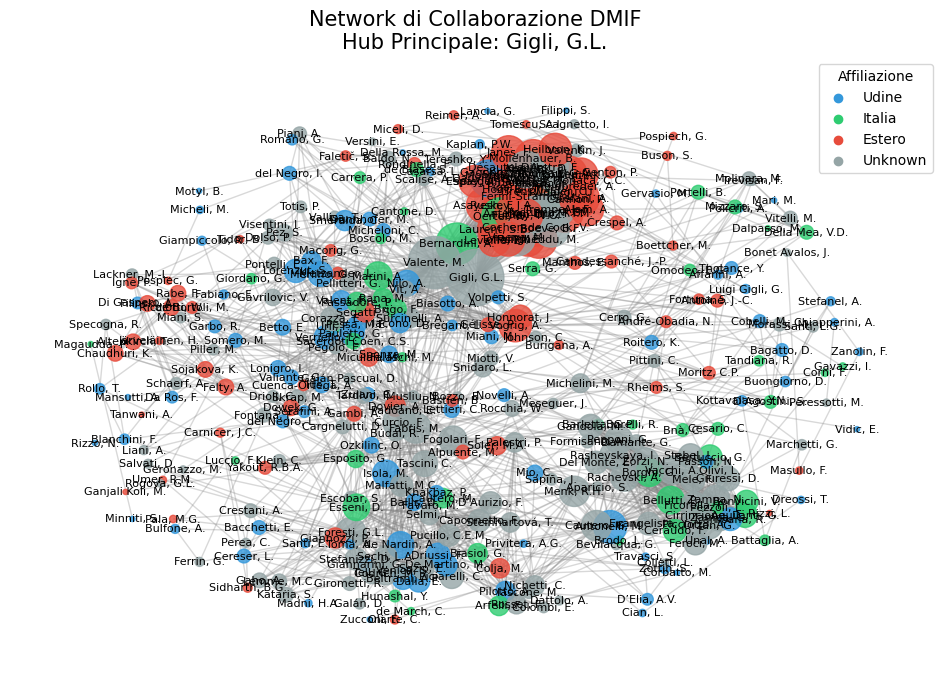


--- SINTESI PROGETTO ---
L'autore centrale assoluto è Gigli, G.L. (Unknown).
La rete mostra cluster di tipo 'Unknown' che si connettono con l'Estero.


In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

# 1. Caricamento Dati
df = pd.read_csv('nuovo_dataset.csv')

def classify_geo(aff):
    if pd.isna(aff): return "Unknown"
    aff = aff.lower()
    if "udine" in aff: return "Udine"
    elif "italy" in aff or "italia" in aff: return "Italia"
    else: return "Estero"

G = nx.Graph()
color_map = []
geo_dict = {}

# 2. Costruzione Rete e Analisi
for _, row in df.iterrows():
    authors = [a.strip() for a in str(row['Authors']).split(';')]
    affiliations = str(row['Affiliations']).split(';')
    kws = [k.strip().lower() for k in str(row['Author Keywords']).split(';') if k != 'nan']
    
    for i, auth in enumerate(authors):
        geo = classify_geo(affiliations[i]) if i < len(affiliations) else "Unknown"
        if auth not in G:
            G.add_node(auth, geo=geo)
            geo_dict[auth] = geo
    
    for i in range(len(authors)):
        for j in range(i + 1, len(authors)):
            G.add_edge(authors[i], authors[j], year=row['Year'])

# 3. Identificazione Leader
centrality = nx.degree_centrality(G)
top_abs = max(centrality, key=centrality.get)

# 4. Preparazione colori per il grafo
# Udine = Blu, Italia = Verde, Estero = Rosso
colors = {'Udine': '#3498db', 'Italia': '#2ecc71', 'Estero': '#e74c3c', 'Unknown': '#95a5a6'}
node_colors = [colors[G.nodes[node]['geo']] for node in G.nodes()]

# 5. Visualizzazione del Grafo
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5, seed=42) # Layout per distanziare i nodi

# Disegno nodi (dimensione basata sulla centralità)
node_sizes = [v * 5000 for v in centrality.values()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')

plt.title(f"Network di Collaborazione DMIF\nHub Principale: {top_abs}", fontsize=15)
plt.axis('off')

# Legenda
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)
plt.legend(title="Affiliazione")

plt.show()

print(f"\n--- SINTESI PROGETTO ---")
print(f"L'autore centrale assoluto è {top_abs} ({geo_dict[top_abs]}).")
print(f"La rete mostra cluster di tipo '{geo_dict[top_abs]}' che si connettono con l'Estero.")
